In [1]:
from langgraph.graph import StateGraph, START, END

from afm_lib.instrument.session import call
from afm_lib.schemas.instrument import to_instrument_state
from afm_lib.schemas.recipe import load_recipe
from afm_lib.states.lib_experiment_state import LibExperimentState
from afm_lib.nodes.next_site_node import next_site_node, route_after_next_site

RECIPE = r"../recipes/plzt_grid_4_200um_above.yaml"

recipe = load_recipe(RECIPE)
sites = [{"index": i, "x_stage_m": s.x_stage_m, "y_stage_m": s.y_stage_m,
          "label": s.label, "status": "pending"}
         for i, s in enumerate(recipe.sites)]
print(f"{recipe.name}: {len(sites)} sites")

plzt_grid: 11 sites


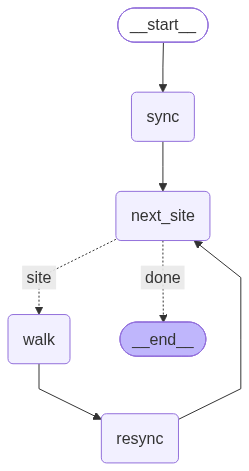

In [2]:
walk_log = []          # filled by walk_stage_node


async def sync_nocal_node(state: LibExperimentState) -> LibExperimentState:
    """Status refresh WITHOUT a scanner calibration — probe_position stays None.
    Deliberate: calibrate_xy_frame is the one prologue step that moves the tip."""
    raw = await call("pfm_get_experiment_status")
    return {"instrument_state": to_instrument_state(raw, scanner_calibrations=None)}


async def walk_stage_node(state: LibExperimentState) -> LibExperimentState:
    """Move the stage to the current site and STOP. No approach, no tip motion,
    no measurement. The tip stays withdrawn for the whole traverse."""
    site = state["sites"][state["site_index"]]
    live = state["instrument_state"].stage_position
    tx, ty = site["x_stage_m"], site["y_stage_m"]

    data = await call("pfm_move_stage", {"x_stage_m": float(tx),
                                         "y_stage_m": float(ty),
                                         "approach_after": False})   # <- the safety bit

    ax, ay = data["x_stage_m"], data["y_stage_m"]
    err = ((ax - tx) ** 2 + (ay - ty) ** 2) ** 0.5
    walk_log.append({"label": site["label"],
                     "req_x": tx, "req_y": ty, "ach_x": ax, "ach_y": ay,
                     "err_m": err, "moved": data.get("moved"),
                     "feedback_on": data.get("feedback_on")})

    print(f"  {site['label']:>7}  req ({tx*1e3:+8.3f},{ty*1e3:+8.3f})  "
          f"ach ({ax*1e3:+8.3f},{ay*1e3:+8.3f}) mm  err {err*1e6:7.1f} um  "
          f"moved={data.get('moved')}  fb={data.get('feedback_on')}")
    return {}


g = StateGraph(LibExperimentState)
g.add_node("sync",  sync_nocal_node)
g.add_node("next_site", next_site_node)
g.add_node("walk",  walk_stage_node)
g.add_node("resync", sync_nocal_node)

g.add_edge(START, "sync")
g.add_edge("sync", "next_site")
g.add_conditional_edges("next_site", route_after_next_site,
                        {"site": "walk", "done": END})
g.add_edge("walk", "resync")
g.add_edge("resync", "next_site")

walk_graph = g.compile()
walk_graph

In [3]:
walk_log.clear()
cfg = {"recursion_limit": 4 * len(sites) + 50}

out = await walk_graph.ainvoke(
    {"recipe": recipe, "sites": sites, "site_index": -1}, cfg)

print(f"\nvisited {len(walk_log)} sites")

[next_site] 1/11  r0c00 -> (+20.891, +12.123) mm
    r0c00  req ( +20.891, +12.123)  ach ( +20.890, +12.123) mm  err     1.0 um  moved=True  fb=False
[next_site] 2/11  r0c01 -> (+16.891, +12.180) mm
    r0c01  req ( +16.891, +12.180)  ach ( +16.891, +12.180) mm  err     0.4 um  moved=True  fb=False
[next_site] 3/11  r0c02 -> (+12.891, +12.236) mm
    r0c02  req ( +12.891, +12.236)  ach ( +12.892, +12.235) mm  err     1.6 um  moved=True  fb=False
[next_site] 4/11  r0c03 -> (+8.891, +12.293) mm
    r0c03  req (  +8.891, +12.293)  ach (  +8.891, +12.293) mm  err     0.2 um  moved=True  fb=False
[next_site] 5/11  r0c04 -> (+4.891, +12.349) mm
    r0c04  req (  +4.891, +12.349)  ach (  +4.891, +12.349) mm  err     0.4 um  moved=True  fb=False
[next_site] 6/11  r0c05 -> (+0.891, +12.406) mm
    r0c05  req (  +0.891, +12.406)  ach (  +0.891, +12.406) mm  err     0.0 um  moved=True  fb=False
[next_site] 7/11  r0c06 -> (-3.109, +12.463) mm
    r0c06  req (  -3.109, +12.463)  ach (  -3.109, +12.